# DAC FIND IT 2026 : Face Spoofing


## 0. Setup

Install & import semua library yang dibutuhkan.

In [ ]:
# Install library tambahan (jalankan sekali, lalu restart runtime jika diminta)
# albumentations: augmentasi gambar yang lebih kaya dibanding torchvision transforms
# scikit-learn  : StratifiedKFold, class_weight, metrik evaluasi
!pip install -q albumentations scikit-learn timm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Library

In [ ]:
import os, random, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset, Subset

# timm: library model pretrained terlengkap (ConvNeXt, EfficientNet, dll)
import timm

# albumentations: augmentasi gambar jauh lebih fleksibel dari torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2

# torchvision hanya dipakai untuk ImageFolder (load struktur folder)
from torchvision import datasets

from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns

from tqdm.auto import tqdm

print("torch       :", torch.__version__)
print("timm        :", timm.__version__)
print("albumentations:", A.__version__)
print("cuda        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu         :", torch.cuda.get_device_name(0))

torch       : 2.10.0+cu128
timm        : 1.0.26
albumentations: 2.0.8
cuda        : True
gpu         : Tesla T4


## 1. Konfigurasi & Reproducibility

In [ ]:
# Reproducibility
# Seed yang sama memastikan hasil eksperimen bisa direproduksi
SEED = 25
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# deterministic=False + benchmark=True -> lebih cepat di GPU, sedikit non-deterministic
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# Path
TRAIN_DATA_ROOT  = '/content/drive/MyDrive/Lombaa/FindIT/Dataset DAC 2026/data_move_clean_3'
TEST_DIR         = Path('/content/drive/MyDrive/Lombaa/FindIT/Dataset DAC 2026/test')
SAMPLE_SUB_PATH  = Path('/content/drive/MyDrive/Lombaa/FindIT/Dataset DAC 2026/samplesubmission.csv')
OUTPUT_CSV       = Path('/content/submission.csv')

assert os.path.isdir(TRAIN_DATA_ROOT), f"Folder tidak ada: {TRAIN_DATA_ROOT}"
print("TRAIN_DATA_ROOT:", TRAIN_DATA_ROOT)
print("Kelas:", sorted([d for d in os.listdir(TRAIN_DATA_ROOT)
                        if os.path.isdir(os.path.join(TRAIN_DATA_ROOT, d))]))

# Hyperparameter
IMG_SIZE    = 224
BATCH_SIZE  = 32
N_SPLITS    = 5     # 5-fold -> tiap fold ~80% train / 20% val
FOLD_EPOCHS = 20


LR_BACKBONE = 1e-5
LR_HEAD     = 1e-4

WEIGHT_DECAY    = 1e-3
DROPOUT         = 0.5
EARLY_STOP_PAT  = 6
NUM_WORKERS     = 2

print(f"\nConfig:")
print(f"  IMG_SIZE        : {IMG_SIZE}")
print(f"  BATCH_SIZE      : {BATCH_SIZE}")
print(f"  N_SPLITS        : {N_SPLITS}")
print(f"  FOLD_EPOCHS     : {FOLD_EPOCHS}")
print(f"  LR backbone/head: {LR_BACKBONE}/{LR_HEAD}")
print(f"  WEIGHT_DECAY    : {WEIGHT_DECAY}")
print(f"  DROPOUT         : {DROPOUT}")
print(f"  EARLY_STOP_PAT  : {EARLY_STOP_PAT}")

Device: cuda
TRAIN_DATA_ROOT: /content/drive/MyDrive/Lombaa/FindIT/Dataset DAC 2026/data_move_clean_3
Kelas: ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']

Config:
  IMG_SIZE        : 224
  BATCH_SIZE      : 32
  N_SPLITS        : 5
  FOLD_EPOCHS     : 20
  LR backbone/head: 1e-05/0.0001
  WEIGHT_DECAY    : 0.001
  DROPOUT         : 0.5
  EARLY_STOP_PAT  : 6


## 2. Data Preparation & Stratified K-Fold

In [ ]:
# Ambil daftar file & label menggunakan ImageFolder (struktur subfolder per kelas)
# ImageFolder otomatis sort kelas secara alfabetis -> konsisten di semua run
_tmp_ds = datasets.ImageFolder(TRAIN_DATA_ROOT)
ALL_SAMPLES = _tmp_ds.samples          # list of (path, label_idx)
labels      = np.array([y for _, y in ALL_SAMPLES], dtype=np.int64)
CLASS_NAMES = _tmp_ds.classes          # ['fake_mannequin', 'fake_mask', ...]
IDX_TO_CLS  = {v: k for k, v in _tmp_ds.class_to_idx.items()}
NUM_CLASSES = len(CLASS_NAMES)
del _tmp_ds

print(f"Total sampel  : {len(labels)}")
print(f"Jumlah kelas  : {NUM_CLASSES}")
print(f"Kelas         : {CLASS_NAMES}")
print(f"\nDistribusi per kelas:")
for i, cls in enumerate(CLASS_NAMES):
    n = int((labels == i).sum())
    print(f"  {cls:<20}: {n} gambar")

# Buat indeks fold menggunakan StratifiedKFold
# Stratified = proporsi kelas dipertahankan di setiap fold
# Penting untuk dataset kecil & imbalanced seperti ini
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_indices = list(skf.split(np.arange(len(labels)), labels))

print(f"\nStratifiedKFold: {N_SPLITS} fold")
print(f"Contoh fold 0 -> train: {len(fold_indices[0][0])} | val: {len(fold_indices[0][1])}")

Total sampel  : 1469
Jumlah kelas  : 6
Kelas         : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']

Distribusi per kelas:
  fake_mannequin      : 193 gambar
  fake_mask           : 261 gambar
  fake_printed        : 105 gambar
  fake_screen         : 193 gambar
  fake_unknown        : 327 gambar
  realperson          : 390 gambar

StratifiedKFold: 5 fold
Contoh fold 0 → train: 1175 | val: 294


## 3. Augmentasi (Albumentations)

Augmentasi adalah cara utama 'memperbanyak' data ketika hanya punya 1500 gambar.

- **Train**: augmentasi kaya -> model melihat variasi gambar yang beragam
- **Val/Test**: tidak ada augmentasi -> evaluasi pada gambar asli
- **TTA** (Test Time Augmentation): prediksi beberapa variasi saat inference -> lebih stabil

In [ ]:
# Normalisasi ImageNet
# ConvNeXt pretrained ImageNet mengharapkan input dinormalisasi dengan nilai ini
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

# Augmentasi Training
# Dirancang untuk mensimulasikan variasi gambar face spoofing di dunia nyata:
# Printed foto: blur, kompresi JPEG, resolusi rendah
# Screen foto: distorsi warna, noise
# Variasi kondisi: pencahayaan, rotasi, flip
train_transforms = A.Compose([
    # Resize sedikit lebih besar lalu random crop -> variasi posisi wajah
    A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),

    # Flip horizontal: wajah kiri/kanan tidak mengubah kelas
    A.HorizontalFlip(p=0.5),

    # Rotasi & shift ringan: simulasi foto tidak lurus
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.1,
        rotate_limit=10, p=0.4
    ),

    # Variasi warna: simulasi perbedaan kamera & pencahayaan
    A.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.05, p=0.6
    ),

    # Blur: simulasi foto cetak difoto ulang (fake_printed, fake_screen)
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MotionBlur(blur_limit=7, p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
    ], p=0.35),

    # Kompresi JPEG: simulasi artefak foto cetak & screenshot
    A.ImageCompression(quality_lower=65, quality_upper=95, p=0.4),

    # Noise ringan: simulasi sensor kamera
    A.GaussNoise(std_range=(0.01, 0.05), p=0.25),

    # Cutout: paksa model tidak bergantung pada satu area wajah
    # Penting untuk 1500 data agar tidak overfit ke fitur spesifik
    A.CoarseDropout(
        max_holes=6, max_height=IMG_SIZE // 10,
        max_width=IMG_SIZE // 10, min_holes=1,
        fill_value=0, p=0.3
    ),

    # Normalisasi + konversi ke tensor PyTorch
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

# Augmentasi Validasi
# TIDAK ada augmentasi acak -> evaluasi pada kondisi gambar asli
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

# TTA Transforms
# TTA = Test Time Augmentation
# Prediksi gambar yang sama dengan 3 variasi berbeda, lalu rata-rata probabilitasnya
# Hasilnya lebih stabil daripada prediksi sekali saja
tta_transforms = [
    # Versi 1: gambar asli (baseline)
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2()
    ]),
    # Versi 2: flip horizontal
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2()
    ]),
    # Versi 3: center crop (sedikit zoom out, fokus ke bagian tengah)
    A.Compose([
        A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
        A.CenterCrop(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2()
    ]),
    # Versi 4: brightness & contrast shift (simulasi variasi pencahayaan)
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2()
    ]),
    # Versi 5: rotasi ringan (simulasi foto tidak lurus)
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Rotate(limit=10, p=1.0),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2()
    ]),
]

print(f"Train transforms : {len(train_transforms)} steps")
print(f"Val transforms   : {len(val_transforms)} steps")
print(f"TTA variants     : {len(tta_transforms)}")

Train transforms : 11 steps
Val transforms   : 3 steps
TTA variants     : 5


/tmp/ipykernel_13422/1776558074.py:39: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=65, quality_upper=95, p=0.4),
/tmp/ipykernel_13422/1776558074.py:46: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


## 4. Dataset & DataLoader

**Urutan (section 4):** kelas `FaceDataset` -> `make_fold_loaders` -> `make_test_loader` -> sanity check batch (satu blok per sel).

In [ ]:
import logging

# Configure logging to show messages from this module
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Custom Dataset yang kompatibel dengan Albumentations
class FaceDataset(Dataset):
    def __init__(self, samples, transform=None, is_test=False):
        # samples: list of (path_str, label_idx) atau list of path_str untuk test
        self.samples   = samples
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.is_test:
            path = self.samples[idx]
            label = -1
        else:
            path, label = self.samples[idx]

        try:
            img = np.array(Image.open(path).convert('RGB'))
        except OSError as e:
            logging.warning(f"Skipping corrupted image: {path} - {e}")
            return None, None

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label

In [ ]:
def make_fold_loaders(train_idx, val_idx, batch_size):
    """Buat DataLoader train & val untuk satu fold."""
    train_samples = [ALL_SAMPLES[i] for i in train_idx]
    val_samples   = [ALL_SAMPLES[i] for i in val_idx]

    train_ds = FaceDataset(train_samples, transform=train_transforms)
    val_ds   = FaceDataset(val_samples,   transform=val_transforms)

    common = dict(
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(NUM_WORKERS > 0),
    )
    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, **common
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size,
        shuffle=False, **common
    )
    return train_loader, val_loader


In [ ]:
# Test dataset (tanpa label, untuk submission)
def make_test_loader(test_paths, batch_size, transform):
    test_ds = FaceDataset(test_paths, transform=transform, is_test=True)
    return DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(NUM_WORKERS > 0),
    )


In [ ]:
# Sanity check loader fold 0
tr_idx_0, va_idx_0 = fold_indices[0]
_tl, _vl = make_fold_loaders(tr_idx_0, va_idx_0, BATCH_SIZE)
imgs, lbls = next(iter(_tl))
print(f"Fold 0  train: {len(tr_idx_0)} | val: {len(va_idx_0)}")
print(f"Batch shape: {imgs.shape} | dtype: {imgs.dtype}")
del _tl, _vl


Fold 0  train: 1175 | val: 294
Batch shape: torch.Size([32, 3, 224, 224]) | dtype: torch.float32


## 5. Model  ConvNeXt-Small + Projection Head (SupCon)

Model dimodifikasi dengan menambahkan **projection head** untuk Supervised Contrastive Learning:
- `backbone` -> ConvNeXt-Small pretrained ImageNet (tidak berubah)
- `projector` -> MLP 2-layer (768 -> 768 -> 128, L2-normalized)  **dipakai saat training SupCon**
- `head` -> classifier linear (768 -> 256 -> 6)  **dipakai saat inference & evaluasi**

Saat `forward(x, return_proj=True)` -> return `(logits, proj_feats)` untuk training hybrid.
Saat `forward(x)` -> return `logits` saja (untuk evaluasi & inference, tidak berubah).


**Urutan (section 5):** definisi `ConvNeXtSmallWithProjection` -> cek jumlah parameter (sel terpisah).


In [ ]:
class ConvNeXtSmallWithProjection(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT, proj_dim=128):
        super().__init__()

        # Backbone
        self.backbone = timm.create_model(
            'convnext_small',
            pretrained=True,
            num_classes=0,
            drop_path_rate=0.1,
        )
        feat_dim = self.backbone.num_features  # ConvNeXt-Small: 768

        # Projection Head (untuk SupCon)
        # MLP 2-layer: feat_dim -> feat_dim -> proj_dim
        # Output di-L2-normalize agar dot-product = cosine similarity
        # Head ini TIDAK dipakai saat inference, hanya saat training SupCon
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.GELU(),
            nn.Linear(feat_dim, proj_dim),
        )

        # Classifier Head
        # Sama persis dengan versi sebelumnya
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(p=dropout),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(p=dropout - 0.1),
            nn.Linear(256, num_classes),
        )

        # Inisialisasi bobot classifier head kecil -> logit awal stabil
        nn.init.normal_(self.head[2].weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.head[2].bias)
        nn.init.normal_(self.head[5].weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.head[5].bias)

        # Inisialisasi projector
        nn.init.normal_(self.projector[0].weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.projector[0].bias)
        nn.init.normal_(self.projector[2].weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.projector[2].bias)

    def forward(self, x, return_proj=False):
        feats  = self.backbone(x)
        logits = self.head(feats)
        if return_proj:
            # L2-normalize projection cosine similarity yang terdefinisi baik
            proj = F.normalize(self.projector(feats), dim=1)
            return logits, proj
        return logits


In [ ]:
# Cek parameter model baru
_m = ConvNeXtSmallWithProjection()
total     = sum(p.numel() for p in _m.parameters()) / 1e6
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad) / 1e6
proj_params = sum(p.numel() for p in _m.projector.parameters()) / 1e6
print(f"Backbone         : ConvNeXt-Small")
print(f"Feature dim      : {_m.backbone.num_features}")
print(f"Projection dim   : 128")
print(f"Projector params : {proj_params:.2f}M")
print(f"Total params     : {total:.1f}M")
print(f"Trainable params : {trainable:.1f}M")
del _m


Backbone         : ConvNeXt-Small
Feature dim      : 768
Projection dim   : 128
Projector params : 0.69M
Total params     : 50.3M
Trainable params : 50.3M


**Urutan (section 6):** kelas `FocalLoss` + `SupConLoss` (satu sel) -> hitung `class_weights_t` & cetak (sel terpisah).


## 6. Loss Function  Focal Loss + Supervised Contrastive Loss

Dua loss dikombinasikan secara hybrid:
- **FocalLoss** (class-weighted, label smoothing) -> optimasi classifier head
- **SupConLoss** -> dorong fitur kelas sama berdekatan, kelas beda berjauhan di embedding space

Formula: `total_loss = α × SupConLoss + (1-α) × FocalLoss` dengan α=0.5

**Mengapa SupCon bagus untuk spoofing detection?**
- `realperson` harus jauh dari semua `fake_*` di embedding space
- Kelas minority (`fake_printed` 105 sampel) tetap bisa belajar representasi yang distinct
- Temperature τ=0.07 -> pembeda yang ketat antara positive dan negative pairs


In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss = down-weight easy examples, fokus ke hard examples.

    Args:
        gamma        : focusing parameter. 2.0 = standar.
                       Naikkan ke 3.0 jika kelas tertentu masih recall rendah.
        label_smoothing: cegah model terlalu confident. 0.1 = standar.
                       Naikkan ke 0.15 jika val F1 jauh di atas test F1.
        weight       : class weights tensor (dari compute_class_weight)
    """
    def __init__(self, gamma=2.0, label_smoothing=0.1, weight=None):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.weight          = weight  # (num_classes,) tensor

    def forward(self, logits, targets):
        # Clamp mencegah NaN dari logit ekstrem saat mixed precision (fp16)
        logits = torch.clamp(logits, -50, 50)

        ce = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt    = torch.exp(-ce)           # probabilitas prediksi benar
        focal = (1 - pt) ** self.gamma * ce
        focal = torch.nan_to_num(focal, nan=0.0, posinf=10.0)
        return focal.mean()


class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al., 2020).

    Mendorong embedding gambar dari kelas yang sama berdekatan,
    dan embedding gambar dari kelas berbeda berjauhan.

    Args:
        temperature : τ  semakin kecil semakin ketat pemisahan. Default: 0.07
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temp = temperature

    def forward(self, features, labels):
        """
        Args:
            features : (B, proj_dim)  L2-normalized projection vectors
            labels   : (B,)  integer class labels
        Returns:
            scalar loss
        """
        device = features.device
        B = features.size(0)

        if B < 2:
            # Tidak bisa hitung contrastive loss dengan 1 sampel
            return torch.tensor(0.0, device=device, requires_grad=True)

        # Similarity matrix ─
        # Karena features sudah L2-normalized, dot product = cosine similarity
        sim = torch.matmul(features, features.T) / self.temp  # (B, B)

        # Stabilkan numerik: kurangi max (tidak mengubah hasil softmax)
        sim = sim - sim.detach().max()

        # Mask positive pairs ─
        labels_row = labels.unsqueeze(0)   # (1, B)
        labels_col = labels.unsqueeze(1)   # (B, 1)
        same_class = (labels_row == labels_col)           # (B, B)
        mask_self  = ~torch.eye(B, dtype=torch.bool, device=device)
        pos_mask   = same_class & mask_self               # exclude self

        # Jika ada kelas yang hanya muncul sekali di batch -> tidak ada positive pair
        # Loss tetap 0 untuk anchor tersebut (pos_mask.sum(1) = 0)
        n_pos = pos_mask.sum(dim=1).float()               # (B,)

        # Contrastive loss
        # Denominator: semua pasangan kecuali self
        exp_sim = torch.exp(sim) * mask_self              # (B, B)
        log_denom = torch.log(exp_sim.sum(dim=1) + 1e-8) # (B,)

        # Log-prob untuk setiap pasangan positif
        log_prob = sim - log_denom.unsqueeze(1)           # (B, B)

        # Rata-rata log-prob atas positive pairs per anchor
        # Clamp n_pos agar tidak bagi nol
        loss_per_anchor = -(log_prob * pos_mask).sum(dim=1) / n_pos.clamp(min=1)

        # Masking: anchor yang tidak punya positive pair tidak ikut dihitung
        has_pos = (n_pos > 0)
        if has_pos.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        return loss_per_anchor[has_pos].mean()


In [ ]:
# Class weights: kelas dengan sampel sedikit -> weight lebih besar
# Dihitung dari seluruh dataset (bukan per-fold) agar konsisten
all_labels_arr = labels  # sudah dihitung di cell Data Preparation
class_weights  = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=all_labels_arr,
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights (balanced):")
for i, (cls, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    n = int((all_labels_arr == i).sum())
    print(f"  {cls:<20}: weight={w:.3f}  (n={n})")


Class weights (balanced):
  fake_mannequin      : weight=1.269  (n=193)
  fake_mask           : weight=0.938  (n=261)
  fake_printed        : weight=2.332  (n=105)
  fake_screen         : weight=1.269  (n=193)
  fake_unknown        : weight=0.749  (n=327)
  realperson          : weight=0.628  (n=390)


## 7. Training Loop


**Urutan (section 7):** `evaluate` -> `train_one_epoch_supcon` -> `fit` (satu fungsi per sel).


In [ ]:
@torch.no_grad()
def evaluate(model, loader, crit):
    """Evaluasi model pada val loader. Return loss, acc, macro_f1, y_true, y_pred."""
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    all_y, all_pred = [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = model(x)
            loss   = crit(logits, y)

        total_loss    += float(loss.item()) * y.size(0)
        pred           = logits.argmax(dim=1)
        total_correct += int((pred == y).sum().item())
        total_n       += int(y.size(0))
        all_y.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

    y_true   = np.concatenate(all_y)
    y_pred   = np.concatenate(all_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return (total_loss / max(total_n, 1),
            total_correct / max(total_n, 1),
            macro_f1, y_true, y_pred)


In [ ]:
def train_one_epoch_supcon(model, loader, focal_crit, supcon_crit,
                            optimizer, scaler, alpha=0.5, grad_clip=1.0):
    """
    Satu epoch training dengan Hybrid Loss: α*SupCon + (1-α)*Focal.

    Args:
        alpha : bobot SupCon loss. 0.5 = seimbang. Naikkan ke 0.7 jika
                representasi masih tumpang tindih, turunkan ke 0.3 jika
                training tidak stabil.
    """
    model.train()
    total_loss, total_focal, total_supcon = 0.0, 0.0, 0.0
    total_correct, total_n = 0, 0

    for x, y in tqdm(loader, desc='train', leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            # return_proj=True -> dapatkan logits DAN projection vector
            logits, proj = model(x, return_proj=True)

            loss_focal  = focal_crit(logits, y)
            loss_supcon = supcon_crit(proj, y)

            # Hybrid loss
            loss = alpha * loss_supcon + (1.0 - alpha) * loss_focal

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        scaler.step(optimizer)
        scaler.update()

        total_loss   += float(loss.item())        * y.size(0)
        total_focal  += float(loss_focal.item())  * y.size(0)
        total_supcon += float(loss_supcon.item()) * y.size(0)

        pred           = logits.argmax(dim=1)
        total_correct += int((pred == y).sum().item())
        total_n       += int(y.size(0))

    n = max(total_n, 1)
    return total_loss / n, total_focal / n, total_supcon / n, total_correct / n


In [ ]:
def fit(model, train_loader, val_loader, focal_crit, supcon_crit,
        optimizer, scheduler, scaler, epochs, patience, ckpt_path,
        alpha=0.5, verbose=True):
    """
    Training loop lengkap dengan:
    - Hybrid SupCon + Focal Loss
    - Early stopping berdasarkan val macro-F1
    - CosineAnnealingWarmRestarts scheduler
    - Simpan checkpoint terbaik otomatis
    """
    best_f1, bad_epochs = -1.0, 0
    history = {k: [] for k in ['epoch', 'lr', 'train_loss', 'train_focal',
                                'train_supcon', 'traincc',
                                'val_loss', 'val_acc', 'val_macro_f1']}

    for epoch in range(1, epochs + 1):
        train_loss, train_focal, train_supcon, train_acc = train_one_epoch_supcon(
            model, train_loader, focal_crit, supcon_crit,
            optimizer, scaler, alpha=alpha
        )
        val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader, focal_crit)

        # CosineAnnealingWarmRestarts: step setiap epoch
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']

        for k, v in zip(history.keys(),
                        [epoch, lr, train_loss, train_focal, train_supcon                         train_acc, val_loss, val_acc, val_f1]):
            history[k].apnd(v)

        print(f"Epoch {epoch:02d}/{epochs} | lr={lr:.2e} | "
              f"loss={train_loss:.4f} (focal={train_focal:.4f} supcon={train_supcon:.4f}) "
              f"acc={train_acc:.4f} | "
              f"val: loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}")

        if verbo:
            print(classification_report(y_true, y_pred,
                                        target_names=CLASS_NAMES, zero_division=0))
            print('-' * 70)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), ckpt_path)
            print(f"  saved be -> {ckpt_path} (val_macro_f1={best_f1:.4f})")
            bad_epochs = 0
        else:
            bad_epochs += 1
            print(f"  patience {bad_epochs}/{patience} (best={best_f1:.4f})")
            if bad_epochs >= patience:
                print(f"  Early stopping di epoch {epoch}.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return best_f1, history


SyntaxError: invalid syntax. Perhaps you forgot a comma? (637765892.py, line 28)

## 8. Cross-Validation Training (5-Fold)  SupCon + Focal Hybrid


**Urutan (section 8):** definisi `run_kfold_cv` -> `plot_cv_histories` -> **jalankan CV** -> ringkasan & `best_fold` -> **plot** history.


In [ ]:
def run_kfold_cv(epochs=FOLD_EPOCHS, patience=EARLY_STOP_PAT,
                 alpha=0.5, verbose=True):
    """
    Latih ConvNeXtSmallWithProjection untuk setiap fold secara berurutan.

    Perubahan dari versi sebelumnya:
    - Model: ConvNeXtSmallWithProjection (ada projection head)
    - Loss: Hybrid SupCon + Focal (alpha=0.5)
    - Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=1)
      -> LR naik-turun mengikuti cosine setiap 10 epoch
      -> Lebih agresif menemukan minimum baru dibanding ReduceLROnPlateau
    - Optimizer: AdamW dengan differential LR (backbone << head)
      + projector ikut head LR (ikut belajar cepat seperti head)
    """
    fold_scores    = []
    fold_histories = []

    for fold, (tr_idx, va_idx) in enumerate(fold_indices):
        print(f"\n{'='*65}")
        print(f"FOLD {fold + 1}/{N_SPLITS}  |  SupCon α={alpha}  |  epochs={epochs}")
        print(f"{'='*65}")

        train_loader, val_loader = make_fold_loaders(tr_idx, va_idx, BATCH_SIZE)

        # Model baru tiap fold
        model = ConvNeXtSmallWithProjection(
            num_classes=NUM_CLASSES, dropout=DROPOUT, proj_dim=128
        ).to(DEVICE)

        # Loss functions
        focal_crit  = FocalLoss(gamma=2.0, label_smoothing=0.1, weight=class_weights_t)
        supcon_crit = SupConLoss(temperature=0.07)

        # Optimizer: Differential LR
        # backbone -> LR kecil (jaga fitur ImageNet)
        # head + projector -> LR besar (perlu belajar dari nol)
        optimizer = optim.AdamW([
            {'params': model.backbone.parameters(),  'lr': LR_BACKBONE},
            {'params': model.head.parameters(),      'lr': LR_HEAD},
            {'params': model.projector.parameters(), 'lr': LR_HEAD},
        ], weight_decay=WEIGHT_DECAY)

        # Scheduler: CosineAnnealingWarmRestarts
        # T_0=10 -> satu siklus cosine = 10 epoch
        # T_mult=1 -> semua siklus sama panjang
        # eta_min=1e-7 -> LR minimum di ujung siklus
        # Cocok untuk 20 epoch: ada 2 siklus penuh -> model bisa keluar local minima
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=1, eta_min=1e-7
        )

        scaler = GradScaler(enabled=torch.cuda.is_available())

        best_f1, hist = fit(
            model, train_loader, val_loader,
            focal_crit, supcon_crit,
            optimizer, scheduler, scaler,
            epochs=epochs,
            patience=patience,
            ckpt_path=f'/content/drive/MyDrive/Lombaa/FindIT/The Overfitted/File Wajib/Best Model/best_fold{fold}.pt',
            alpha=alpha,
            verbose=verbose,
        )

        fold_scores.append(best_f1)
        fold_histories.append(hist)
        print(f"Fold {fold + 1} selesai  best val_macro_f1 = {best_f1:.4f}")

        del model, optimizer, scheduler, scaler, focal_crit, supcon_crit
        gc.collect()
        torch.cuda.empty_cache()

    return fold_scores, fold_histories


In [ ]:
def plot_cv_histories(fold_histories, best_fold_idx):
    """Plot val loss / acc / macro-F1 untuk semua fold; fold terbaik garis lebih tebal."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    denom = max(N_SPLITS - 1, 1)
    for fold, hist in enumerate(fold_histories):
        ep = hist['epoch']
        if not ep:
            continue
        c     = plt.cm.tab10(fold / denom)
        lw    = 2.8 if fold == best_fold_idx else 1.15
        alpha = 1.0 if fold == best_fold_idx else 0.55
        z     = 3   if fold == best_fold_idx else 1
        axes[0].plot(ep, hist['val_loss'],     '-', color=c, lw=lw, alpha=alpha, zorder=z, label=f'Fold {fold+1}')
        axes[1].plot(ep, hist['val_acc'],      '-', color=c, lw=lw, alpha=alpha, zorder=z, label=f'Fold {fold+1}')
        axes[2].plot(ep, hist['val_macro_f1'], '-', color=c, lw=lw, alpha=alpha, zorder=z, label=f'Fold {fold+1}')

    for ax, title, ylabel in zip(
        axes,
        ['Val loss (tiap fold)', 'Val accuracy (tiap fold)', 'Val macro-F1 (tiap fold)'],
        ['Loss', 'Accuracy', 'Macro F1']
    ):
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)
    axes[2].set_ylim(bottom=0, top=1.02)
    fig.suptitle('CV  garis tebal = fold terbaik', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('/content/history_cv_folds.png', dpi=140, bbox_inches='tight')
    plt.show()

    # Plot detail fold terbaik ─
    h = fold_histories[best_fold_idx]
    ep = h['epoch']
    if not ep:
        return

    fig2, axes2 = plt.subplots(1, 4, figsize=(22, 4))

    # Loss breakdown
    axes2[0].plot(ep, h['train_loss'],   '--', color='#2ecc71', lw=2, label='train total')
    axes2[0].plot(ep, h['val_loss'],     '-',  color='#e74c3c', lw=2, label='val')
    axes2[0].set_title(f'Loss  fold {best_fold_idx+1} (terbaik)')
    axes2[0].set_xlabel('Epoch'); axes2[0].legend(); axes2[0].grid(True, alpha=0.3)

    # SupCon vs Focal breakdown
    axes2[1].plot(ep, h['train_focal'],  '-', color='#e74c3c', lw=2, label='Focal')
    axes2[1].plot(ep, h['train_supcon'], '-', color='#3498db', lw=2, label='SupCon')
    axes2[1].set_title('Train Loss Breakdown (Focal vs SupCon)')
    axes2[1].set_xlabel('Epoch'); axes2[1].legend(); axes2[1].grid(True, alpha=0.3)

    # Accuracy
    axes2[2].plot(ep, h['train_acc'], '--', color='#3498db', lw=2, label='train')
    axes2[2].plot(ep, h['val_acc'],   '-',  color='#9b59b6', lw=2, label='val')
    axes2[2].set_title('Accuracy')
    axes2[2].set_xlabel('Epoch'); axes2[2].legend(); axes2[2].grid(True, alpha=0.3); axes2[2].set_ylim(0, 1.02)

    # Learning rate
    axes2[3].plot(ep, h['lr'], color='#f39c12', lw=2)
    axes2[3].set_title('Learning rate (CosineWarmRestarts)')
    axes2[3].set_xlabel('Epoch'); axes2[3].set_ylabel('LR'); axes2[3].set_yscale('log')
    axes2[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/history_best_fold.png', dpi=140, bbox_inches='tight')
    plt.show()


In [ ]:
# Jalankan CV
cv_scores, fold_histories = run_kfold_cv(
    epochs=FOLD_EPOCHS,
    patience=EARLY_STOP_PAT,
    verbose=True,
)



FOLD 1/5  |  SupCon α=0.5  |  epochs=20


/tmp/ipykernel_13422/40721363.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


train:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 01/20 | lr=9.76e-06 | loss=2.1656 (focal=1.2392 supcon=3.0920) acc=0.4613 | val: loss=1.0969 acc=0.8401 f1=0.8184
                precision    recall  f1-score   support

fake_mannequin       0.77      0.92      0.84        39
     fake_mask       0.72      0.85      0.78        52
  fake_printed       0.75      0.57      0.65        21
   fake_screen       0.79      0.97      0.87        39
  fake_unknown       0.98      0.89      0.94        65
    realperson       0.94      0.76      0.84        78

      accuracy                           0.84       294
     macro avg       0.82      0.83      0.82       294
  weighted avg       0.85      0.84      0.84       294

----------------------------------------------------------------------
  ✓ saved best -> /content/drive/MyDrive/Lombaa/FindIT/The Overfitted/File Wajib/Best Model/best_fold0.pt (val_macro_f1=0.8184)


train:   0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch 13/20 | lr=7.96e-06 | loss=0.9636 (focal=0.1226 supcon=1.8046) acc=0.9745 | val: loss=0.1579 acc=0.9625 f1=0.9640
                precision    recall  f1-score   support

fake_mannequin       1.00      1.00      1.00        38
     fake_mask       1.00      0.92      0.96        52
  fake_printed       0.95      0.95      0.95        21
   fake_screen       0.93      1.00      0.96        39
  fake_unknown       1.00      0.91      0.95        65
    realperson       0.92      1.00      0.96        78

      accuracy                           0.96       293
     macro avg       0.97      0.96      0.96       293
  weighted avg       0.97      0.96      0.96       293

----------------------------------------------------------------------
  patience 4/6 (best=0.9706)


train:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 14/20 | lr=6.58e-06 | loss=0.9624 (focal=0.1210 supcon=1.8038) acc=0.9736 | val: loss=0.1833 acc=0.9522 f1=0.9562
                precision    recall  f1-score   support

fake_mannequin       0.95      1.00      0.97        38
     fake_mask       0.98      0.94      0.96        52
  fake_printed       1.00      0.95      0.98        21
   fake_screen       0.93      0.95      0.94        39
  fake_unknown       1.00      0.91      0.95        65
    realperson       0.90      0.97      0.94        78

      accuracy                           0.95       293
     macro avg       0.96      0.95      0.96       293
  weighted avg       0.95      0.95      0.95       293

----------------------------------------------------------------------
  patience 5/6 (best=0.9706)


train:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 15/20 | lr=5.05e-06 | loss=0.9569 (focal=0.1158 supcon=1.7980) acc=0.9770 | val: loss=0.1522 acc=0.9522 f1=0.9501
                precision    recall  f1-score   support

fake_mannequin       1.00      0.97      0.99        38
     fake_mask       0.96      0.98      0.97        52
  fake_printed       0.87      0.95      0.91        21
   fake_screen       0.93      0.95      0.94        39
  fake_unknown       0.98      0.94      0.96        65
    realperson       0.94      0.94      0.94        78

      accuracy                           0.95       293
     macro avg       0.95      0.95      0.95       293
  weighted avg       0.95      0.95      0.95       293

----------------------------------------------------------------------
  patience 6/6 (best=0.9706)
  Early stopping di epoch 15.
Fold 5 selesai  best val_macro_f1 = 0.9706


In [ ]:
import numpy as np
# Ringkasan Cross-Validation
print("\n=== Ringkasan Cross-Validation ===")
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1}: val_macro_f1 = {s:.4f}")
print(f"  Mean : {np.mean(cv_scores):.4f}")
print(f"  Std  : {np.std(cv_scores):.4f}")

best_fold      = int(np.argmax(cv_scores))
BEST_FOLD_CKPT = f'/content/drive/MyDrive/Lombaa/FindIT/The Overfitted/File Wajib/Best Model/best_fold{best_fold}.pt'

print(f"\nCheckpoint terbaik: {BEST_FOLD_CKPT} (fold {best_fold+1}, F1={cv_scores[best_fold]:.4f})")


=== Ringkasan Cross-Validation ===
  Fold 1: val_macro_f1 = 0.9336
  Fold 2: val_macro_f1 = 0.9261
  Fold 3: val_macro_f1 = 0.9710
  Fold 4: val_macro_f1 = 0.9638
  Fold 5: val_macro_f1 = 0.9706
  Mean : 0.9530
  Std  : 0.0192

Checkpoint terbaik: /content/drive/MyDrive/Lombaa/FindIT/The Overfitted/File Wajib/Best Model/best_fold2.pt (fold 3, F1=0.9710)


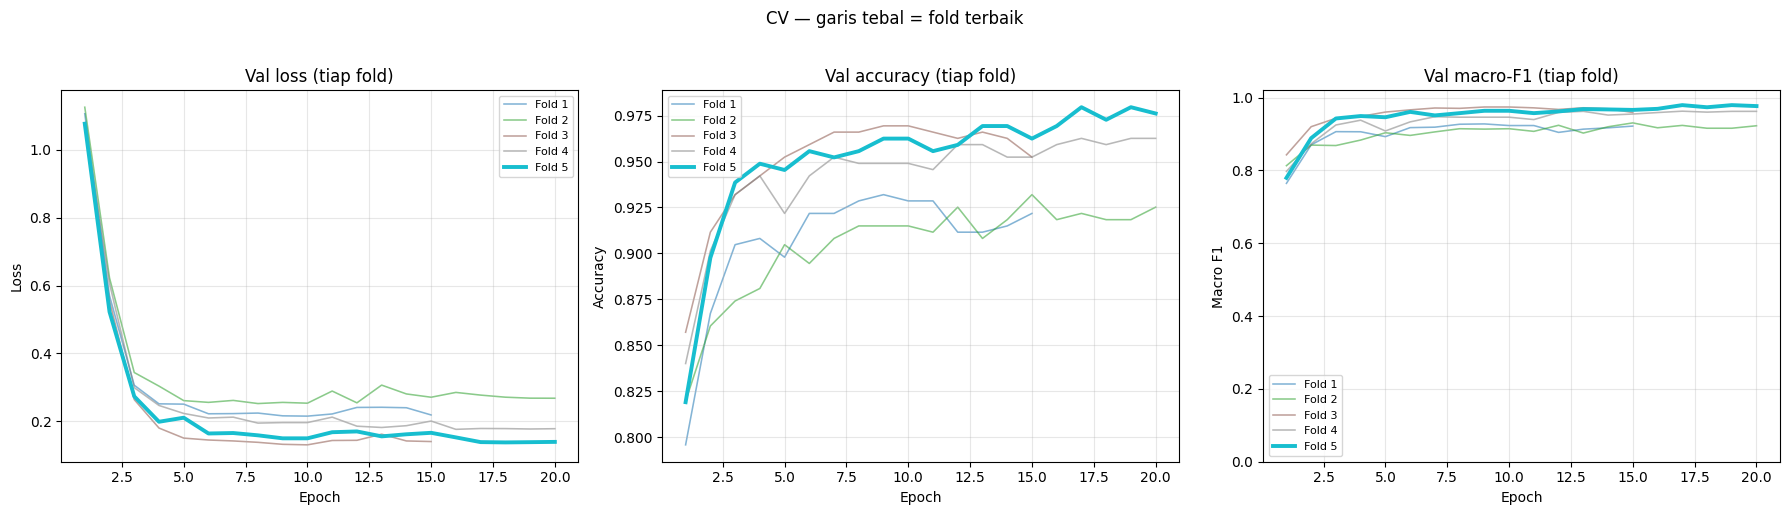

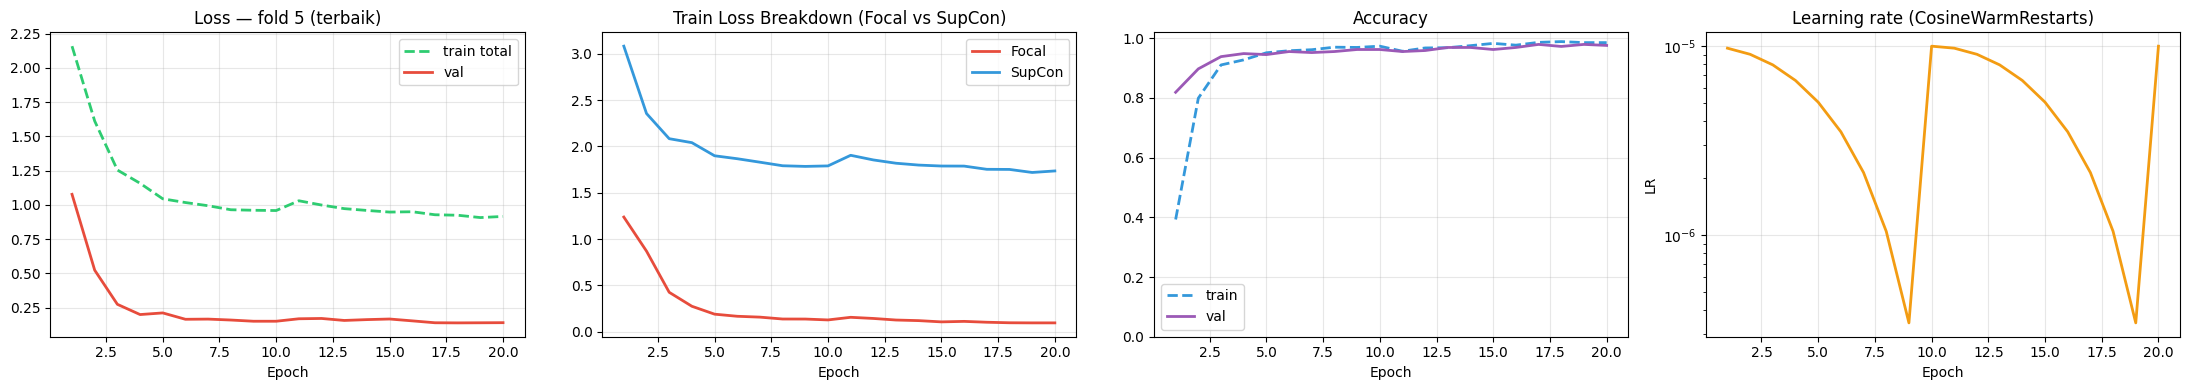

In [ ]:
# Plot history (butuh cv_scores, fold_histories, best_fold dari sel sebelumnya)
plot_cv_histories(fold_histories, best_fold)


## 9. Evaluasi Final (Fold Terbaik)


**Urutan (section 9):** definisi `plot_confusion_matrices` -> load model & evaluasi -> visualisasi (sel terpisah).


In [ ]:
def plot_confusion_matrices(y_true, y_pred, save_path='/content/confusion_matrix.png'):
    """Heatmap confusion matrix: jumlah + recall per baris (normalisasi)."""
    cm = confusion_matrix(y_true, y_pred)
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(np.float64), np.maximum(row_sum, 1))

    fig, axes = plt.subplots(1, 2, figsize=(17, 7))

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='turbo', linewidths=0.65, linecolor='white',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0],
        cbar_kws={'label': 'Jumlah', 'shrink': 0.82},
        square=True,
    )
    axes[0].set_facecolor('#f0f2f5')
    axes[0].set_title('Confusion matrix (jumlah)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Prediksi', fontsize=11)
    axes[0].set_ylabel('Label benar', fontsize=11)
    axes[0].tick_params(axis='x', rotation=35)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='mako', linewidths=0.65, linecolor='white',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
        vmin=0, vmax=1,
        cbar_kws={'label': 'Recall (baris)', 'shrink': 0.82},
        square=True,
    )
    axes[1].set_facecolor('#f0f2f5')
    axes[1].set_title('Recall per kelas (baris dinormalisasi)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Prediksi', fontsize=11)
    axes[1].set_ylabel('Label benar', fontsize=11)
    axes[1].tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# Load checkpoint fold terbaik + evaluasi pada val split
# Gunakan ConvNeXtSmallWithProjection (class baru dengan projection head)
model = ConvNeXtSmallWithProjection(num_classes=NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
model.load_state_dict(torch.load(BEST_FOLD_CKPT, map_location=DEVICE))
model.eval()

focal_crit = FocalLoss(gamma=2.0, label_smoothing=0.1, weight=class_weights_t)

_tr_best, _va_best = fold_indices[best_fold]
_, val_loader_best = make_fold_loaders(_tr_best, _va_best, BATCH_SIZE)

val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader_best, focal_crit)
print(f"=== Evaluasi Final (Fold {best_fold+1}) ===")
print(f"Val Loss    : {val_loss:.4f}")
print(f"Val Acc     : {val_acc:.4f}")
print(f"Macro F1    : {val_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


=== Evaluasi Final (Fold 3) ===
Val Loss    : 0.1266
Val Acc     : 0.9694
Macro F1    : 0.9710

                precision    recall  f1-score   support

fake_mannequin       1.00      0.92      0.96        39
     fake_mask       0.91      0.98      0.94        52
  fake_printed       0.95      1.00      0.98        21
   fake_screen       1.00      1.00      1.00        38
  fake_unknown       0.98      0.97      0.98        66
    realperson       0.97      0.96      0.97        78

      accuracy                           0.97       294
     macro avg       0.97      0.97      0.97       294
  weighted avg       0.97      0.97      0.97       294



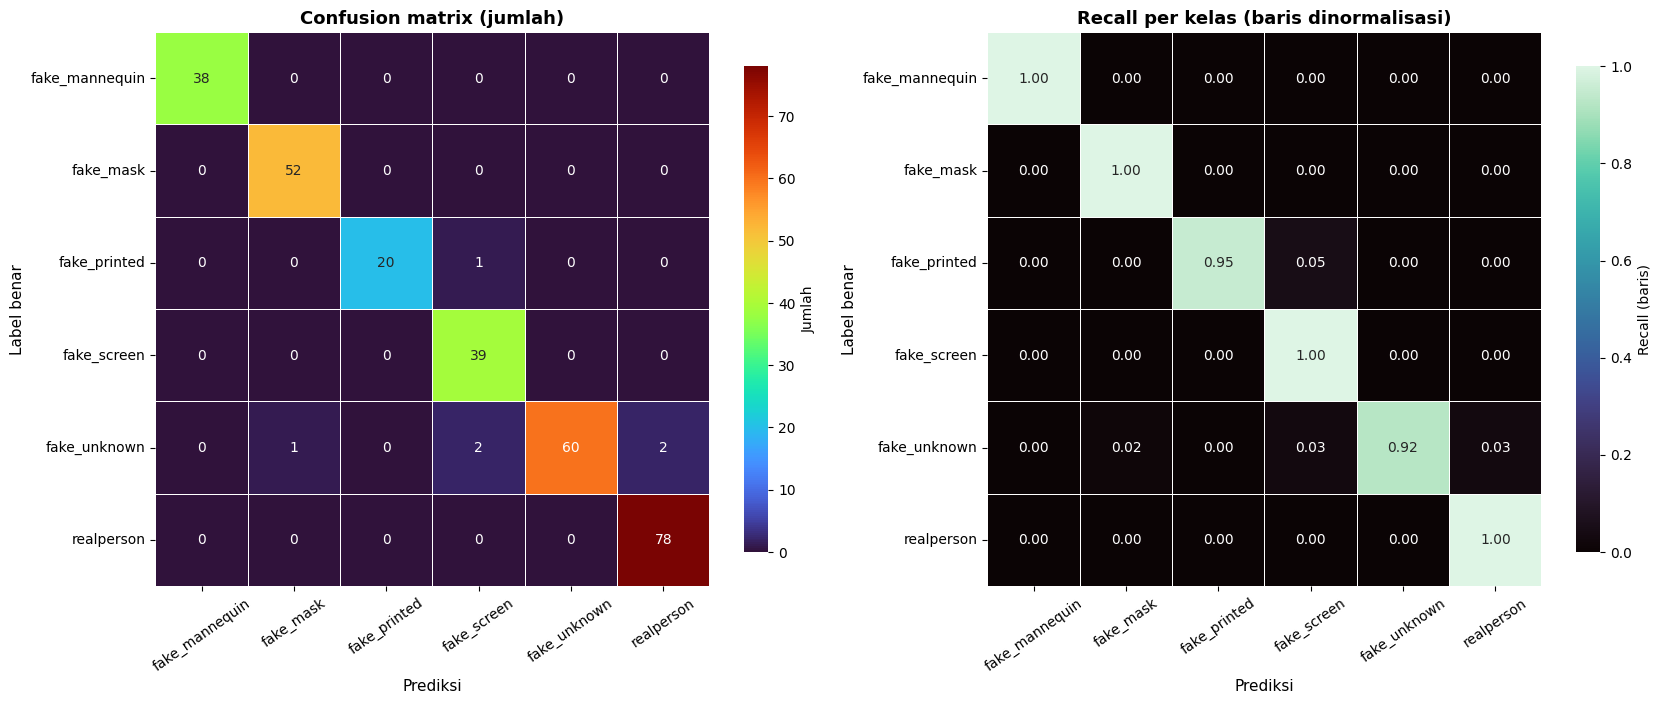


=== Per-Class Recall ===
  fake_mannequin      : 1.0000  ████████████████████ (38 sampel)
  fake_mask           : 1.0000  ████████████████████ (52 sampel)
  fake_printed        : 0.9524  ███████████████████ (21 sampel)
  fake_screen         : 1.0000  ████████████████████ (39 sampel)
  fake_unknown        : 0.9231  ██████████████████ (65 sampel)
  realperson          : 1.0000  ████████████████████ (78 sampel)


In [ ]:
# Visualisasi confusion matrix + ringkasan recall per kelas
plot_confusion_matrices(y_true, y_pred)

print("\n=== Per-Class Recall ===")
for i, cls in enumerate(CLASS_NAMES):
    mask = (np.array(y_true) == i)
    if mask.sum() > 0:
        recall = (np.array(y_pred)[mask] == i).sum() / mask.sum()
        bar = '█' * int(recall * 20)
        print(f"  {cls:<20}: {recall:.4f}  {bar} ({mask.sum()} sampel)")

## 10. Inference + TTA + Ensemble Submission

TTA (Test Time Augmentation) + Ensemble semua 5 fold:
- Load setiap checkpoint fold
- Prediksi test set dengan 5 variasi TTA
- Rata-rata probabilitas dari **semua fold × semua TTA** -> prediksi lebih stabil


**Urutan (section 10):** kumpulkan path test -> definisi `predict_tta` -> inference -> tulis submission CSV.


In [ ]:
# Kumpulkan semua path gambar test
search_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
test_records = []
for ext in search_exts:
    test_records.extend(TEST_DIR.glob(f'*{ext}'))
test_records = sorted(test_records)

print(f"Gambar test ditemukan: {len(test_records)}")
if len(test_records) == 0:
    print(f"[ERROR] Tidak ada gambar di {TEST_DIR}  cek path!")


Gambar test ditemukan: 404


In [ ]:
@torch.no_grad()
def predict_tta(model, test_paths, tta_tfms, batch_size=BATCH_SIZE):
    """
    Inference dengan TTA.
    Untuk setiap transform TTA, prediksi semua gambar lalu simpan probabilitas.
    Akhirnya rata-rata probabilitas semua TTA -> prediksi final.
    """
    model.eval()
    all_probs = []   # list of (N, num_classes) per TTA variant

    for tfm_idx, tfm in enumerate(tta_tfms):
        loader = make_test_loader(
            [str(p) for p in test_paths], batch_size, tfm
        )
        probs_tta = []

        for imgs, _ in tqdm(loader, desc=f'TTA {tfm_idx+1}/{len(tta_tfms)}', leave=False):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(imgs)
                logits = torch.clamp(logits, -50, 50)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            probs_tta.append(probs)

        all_probs.append(np.concatenate(probs_tta, axis=0))  # (N, C)
        print(f"  TTA variant {tfm_idx+1} selesai")

    # Rata-rata probabilitas semua TTA variant
    final_probs = np.mean(all_probs, axis=0)   # (N, C)
    final_preds = final_probs.argmax(axis=1)   # (N,)
    return final_probs, final_preds

In [ ]:
# Ensemble semua fold: load tiap checkpoint -> TTA -> rata-rata probabilitas
print("\nMulai inference dengan ensemble semua fold + TTA...")
all_fold_probs = []

for fold in range(N_SPLITS):
    ckpt_path = f'/content/drive/MyDrive/Lombaa/FindIT/The Overfitted/File Wajib/Best Model/best_fold{fold}.pt'
    print(f"\nLoad checkpoint fold {fold + 1}/{N_SPLITS}: {ckpt_path}")
    # Gunakan ConvNeXtSmallWithProjection (sama dengan class yang ditraining)
    m = ConvNeXtSmallWithProjection(num_classes=NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    fold_probs, _ = predict_tta(m, test_records, tta_transforms)
    all_fold_probs.append(fold_probs)
    del m
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  Fold {fold + 1} selesai")

# Rata-rata probabilitas semua fold -> prediksi final
test_probs  = np.mean(all_fold_probs, axis=0)   # (N, num_classes)
test_preds  = test_probs.argmax(axis=1)          # (N,)
test_labels = [CLASS_NAMES[i] for i in test_preds]

print("\nDistribusi prediksi test (ensemble semua fold):")
for cls, cnt in Counter(test_labels).most_common():
    print(f"  {cls:<20}: {cnt}")



Mulai inference dengan ensemble semua fold + TTA...

Load checkpoint fold 1/5: /content/drive/MyDrive/Lombaa/FindIT/The Overfitted/File Wajib/Best Model/best_fold0.pt


TTA 1/5:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  TTA variant 1 selesai


TTA 2/5:   0%|          | 0/13 [00:00<?, ?it/s]

...

^^^^^^^^^^^^^^^^^^^^^^^
^^^AssertionError^: ^can only test a child process^
^^^^^
AssertionErrorcan only test a child process: 
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c0744f8fe20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiPro

  TTA variant 4 selesai


TTA 5/5:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c0744f8fe20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c0744f8fe20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packa

  TTA variant 5 selesai
  Fold 5 selesai

Distribusi prediksi test (ensemble semua fold):
  realperson          : 102
  fake_screen         : 71
  fake_mask           : 70
  fake_printed        : 61
  fake_mannequin      : 52
  fake_unknown        : 48


In [ ]:
# Buat submission CSV─
if SAMPLE_SUB_PATH.exists():
    sub = pd.read_csv(SAMPLE_SUB_PATH)

    # Deteksi nama kolom id & label secara otomatis
    id_col  = [c for c in sub.columns
               if c.lower() in ['id', 'filename', 'image_id', 'file_name', 'name']][0]
    lbl_col = [c for c in sub.columns
               if c.lower() in ['label', 'class', 'prediction', 'target', 'category']][0]

    # Map prediksi ke submission: cocokkan via filename/stem
    fname_to_label = {p.name: l for p, l in zip(test_records, test_labels)}
    stem_to_label  = {p.stem: l for p, l in zip(test_records, test_labels)}

    def map_label(x):
        x = str(x)
        if x in fname_to_label:
            return fname_to_label[x]
        stem = Path(x).stem
        if stem in stem_to_label:
            return stem_to_label[stem]
        return None

    sub[lbl_col] = sub[id_col].apply(map_label)
    nan_count    = sub[lbl_col].isna().sum()

    if nan_count > 0:
        fallback     = Counter(test_labels).most_common(1)[0][0]
        sub[lbl_col] = sub[lbl_col].fillna(fallback)
        print(f"[WARNING] {nan_count} baris tidak cocok -> fallback ke '{fallback}'")
    else:
        print("Semua baris berhasil diprediksi!")

    sub.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSubmission disimpan: {OUTPUT_CSV}")
    print(sub.head(10))

else:
    # Jika tidak ada sample submission, buat dari scratch
    sub = pd.DataFrame({
        'filename': [p.name for p in test_records],
        'label'   : test_labels,
    })
    sub.to_csv(OUTPUT_CSV, index=False)
    print(f"Submission disimpan: {OUTPUT_CSV}")
    print(sub.head(10))


Semua baris berhasil diprediksi!

Submission disimpan: /content/submission.csv
         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004      realperson
4  test_005    fake_printed
5  test_006  fake_mannequin
6  test_007       fake_mask
7  test_008  fake_mannequin
8  test_009       fake_mask
9  test_010     fake_screen


## 11. Download Submission

In [ ]:
# Download file submission ke komputer lokal
from google.colab import files
files.download(str(OUTPUT_CSV))
print("File submission berhasil didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File submission berhasil didownload!



=== Contoh Gambar Validasi yang Salah Klasifikasi ===

Sampel 100 (Path: printed_074.jpg):
  True Label    : fake_printed
  Predicted Label : fake_screen


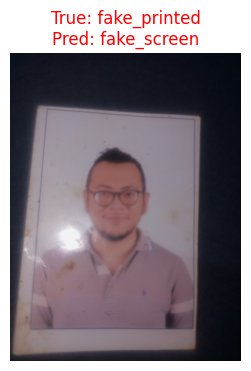


Sampel 155 (Path: screen_097.jpg):
  True Label    : fake_unknown
  Predicted Label : fake_screen


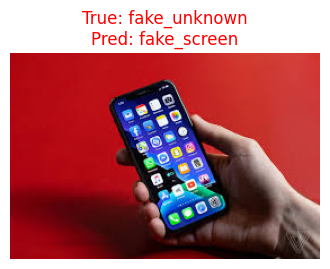


Sampel 156 (Path: screen_228.jpg):
  True Label    : fake_unknown
  Predicted Label : fake_screen


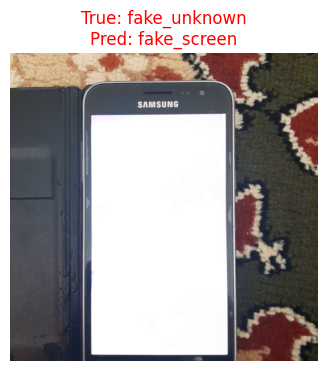


Sampel 158 (Path: unknown_009.jpg):
  True Label    : fake_unknown
  Predicted Label : realperson


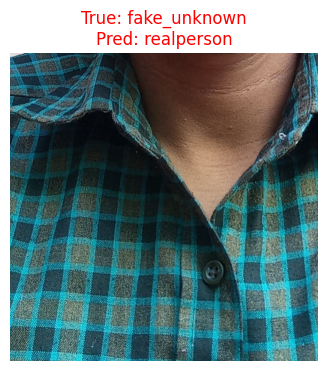


Sampel 213 (Path: unknown_316.jpeg):
  True Label    : fake_unknown
  Predicted Label : fake_mask


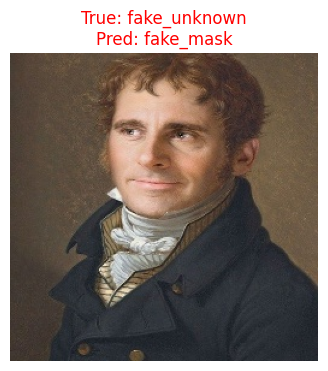


Sampel 214 (Path: unknown_331.jpg):
  True Label    : fake_unknown
  Predicted Label : realperson


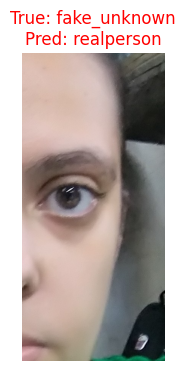

Menampilkan 6 dari total 6 gambar yang salah klasifikasi.


In [ ]:
print("\n=== Contoh Gambar Validasi yang Salah Klasifikasi ===")

misclassified_count = 0
MAX_DISPLAY = 10

# val_loader_best, y_true, y_pred, CLASS_NAMES sudah tersedia dari eksekusi sebelumnya

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        if misclassified_count >= MAX_DISPLAY:
            break

        # Mendapatkan path gambar asli dari dataset
        # val_loader_best.dataset.samples adalah list of (path, label_idx)
        img_path, _ = val_loader_best.dataset.samples[i]

        true_class = CLASS_NAMES[y_true[i]]
        pred_class = CLASS_NAMES[y_pred[i]]

        print(f"\nSampel {i+1} (Path: {Path(img_path).name}):")
        print(f"  True Label    : {true_class}")
        print(f"  Predicted Label : {pred_class}")

        # Tampilkan gambar
        plt.figure(figsize=(4, 4))
        img = Image.open(img_path).convert('RGB')
        plt.imshow(img)
        plt.title(f"True: {true_class}\nPred: {pred_class}", color='red')
        plt.axis('off')
        plt.show()

        misclassified_count += 1

if misclassified_count == 0:
    print("Tidak ada gambar yang salah klasifikasi di set validasi ini.")
else:
    print(f"Menampilkan {misclassified_count} dari total {len([_ for tr, pr in zip(y_true, y_pred) if tr != pr])} gambar yang salah klasifikasi.")


In [ ]:
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader # Ensure DataLoader is imported

# --- Export Test Probabilities ---
# 'test_probs' and 'test_records' are already available from previous execution
print("\n--- Exporting Test Probabilities ---")
test_filenames = [p.name for p in test_records]
test_prob_df = pd.DataFrame(test_probs, columns=[f'prob_{cls}' for cls in CLASS_NAMES])
test_prob_df.insert(0, 'filename', test_filenames)
test_prob_df.to_csv('/content/test_probabilities.csv', index=False)
print("Test probabilities saved to /content/test_probabilities.csv")

# --- Export Validation Probabilities ---
# Define a helper function to get probabilities from a DataLoader
@torch.no_grad()
def get_probs_for_loader(model, loader):
    model.eval()
    all_y_true = []
    all_probs = []

    for x, y in tqdm(loader, desc='Calculating Val Probs', leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = model(x)
            logits = torch.clamp(logits, -50, 50) # Clamp to prevent NaN from extreme logits
        probs = F.softmax(logits, dim=1).cpu().numpy()

        all_y_true.append(y.cpu().numpy())
        all_probs.append(probs)

    y_true_all = np.concatenate(all_y_true)
    probs_all = np.concatenate(all_probs)
    return y_true_all, probs_all


# 'model' (best fold model) and 'val_loader_best' are available from previous execution
print("\n--- Exporting Validation Probabilities ---")

# Re-create val_loader specifically for probability export with num_workers=0
# to avoid DataLoader worker issues.
val_dataset_for_probs = val_loader_best.dataset
val_loader_for_probs = DataLoader(
    val_dataset_for_probs,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0, # Set to 0 to prevent worker issues
    pin_memory=torch.cuda.is_available(),
)

val_y_true, val_probs = get_probs_for_loader(model, val_loader_for_probs)

# Get validation filenames
val_filenames = [Path(s[0]).name for s in val_loader_best.dataset.samples]

# Create DataFrame for validation probabilities
val_prob_df = pd.DataFrame(val_probs, columns=[f'prob_{cls}' for cls in CLASS_NAMES])
val_prob_df.insert(0, 'filename', val_filenames)
val_prob_df.insert(1, 'true_label_idx', val_y_true)
val_prob_df.insert(2, 'true_label_name', [CLASS_NAMES[idx] for idx in val_y_true])
val_prob_df.to_csv('/content/validation_probabilities.csv', index=False)
print("Validation probabilities saved to /content/validation_probabilities.csv")

Exception ignored in: <function tqdm.__del__ at 0x79c283e9f2e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'



--- Exporting Test Probabilities ---
✓ Test probabilities saved to /content/test_probabilities.csv

--- Exporting Validation Probabilities ---


Calculating Val Probs:   0%|          | 0/10 [00:00<?, ?it/s]

✓ Validation probabilities saved to /content/validation_probabilities.csv
